Disclaimer: the homework is entirely done manully. But we have used Claude to capture potential mistakes.

In [31]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("../data/project_long_treasury_20260817.xlsx")
specs_data = pd.read_excel(data_path, sheet_name="specs")
long_bond_data = pd.read_excel(
    data_path, sheet_name="long bond", index_col="date", parse_dates=True
)
yields_data = pd.read_excel(
    data_path, sheet_name="yields", index_col="date", parse_dates=True
)
cash_data = pd.read_excel(
    data_path, sheet_name="cash rates", index_col="date", parse_dates=True
)

START = pd.Timestamp("2024-01-02")
ASSESS = pd.Timestamp("2026-08-17")

In [44]:
# 1.1


def question_1_1():
    result = {}
    result["ticker"] = specs_data.loc[specs_data["field"] == "ticker", "value"].iloc[0]
    result["issue date"] = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "issue date", "value"].iloc[0]
    )
    result["coupon"] = specs_data.loc[specs_data["field"] == "coupon", "value"].iloc[0]
    result["maturity"] = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "maturity date", "value"].iloc[0]
    )
    result["dirty price"] = long_bond_data.loc[START]["dirty"]
    result["accrued interest"] = long_bond_data.loc[START]["accrued"]
    result["YTM"] = long_bond_data.loc[START]["ytm"]
    result["remaining maturity"] = (result["maturity"] - START).days / 365

    result = pd.DataFrame([result])
    print(result.to_string(index=False))


question_1_1()

        ticker issue date  coupon   maturity  dirty price  accrued interest  YTM  remaining maturity
912810RE0 Govt 2014-02-18   3.625 2044-02-15    92.722826          1.379076 4.27           20.134247


A generic 30-year yield is a benchmark, so it always refers to a bond with about 30 years to maturity.

Our bond was issued on 2014-02-18 as a 30-year maturing 2044-02-15, so by 2024-01-02 — ten years later — it has only 20.1 years left.

They are also different kinds of objects: the bond is a security with a fixed 3.625% coupon and a price you can buy and mark, while the generic 30-year is only a quoted rate.

Comparing the two on the same day, this bond yields 4.27 against the benchmark's 4.0708.

In [ ]:
# 1.2


def question_1_2():
    head = long_bond_data.head(3).copy()
    head["clean + accrued"] = head["clean"] + head["accrued"]
    head["price gap"] = head["clean + accrued"] - head["dirty"]
    print(
        head[["clean", "accrued", "dirty", "clean + accrued", "price gap"]].to_string()
    )
    print()
    # total return index = ((clean price + accrued) - bond price) / bond price
    tri = long_bond_data["total return index"]
    tri_ret = tri.iloc[1] / tri.iloc[0] - 1
    dirty_ret = long_bond_data["dirty"].iloc[1] / long_bond_data["dirty"].iloc[0] - 1
    coupon_date_in_sample = long_bond_data[long_bond_data["coupon cash"] != 0]["coupon cash"]
    print(f"total return index return = {tri_ret:.8f}")
    print(f"dirty price return         = {dirty_ret:.8f}")
    print(f"difference                 = {tri_ret - dirty_ret:.2e}")
    print()
    print(
        f"coupon in sample:\n{coupon_date_in_sample}"
    )


question_1_2()

                clean   accrued      dirty  clean + accrued  price gap
date                                                                  
2024-01-02  91.343750  1.379076  92.722826        92.722826        0.0
2024-01-03  91.484375  1.388927  92.873302        92.873302        0.0
2024-01-04  90.484375  1.398777  91.883152        91.883152        0.0

total return index return = 0.00162285
dirty price return         = 0.00162285
difference                 = 2.22e-16

coupon in sample:
date
2024-02-15    1.8125
2024-08-15    1.8125
2025-02-17    1.8125
2025-08-15    1.8125
2026-02-16    1.8125
2026-08-17    1.8125
Name: coupon cash, dtype: float64


Dirty equals clean plus accrued to the last decimal on all three days, and the first index return matches the dirty-price return exactly because no coupon was paid between them. That equivalence breaks on the six coupon dates in the sample: accrued resets to zero and the dirty price drops by the coupon even though the holder lost nothing. The total-return index adds the coupon cash back, so it is the only series that measures what the position actually earned.

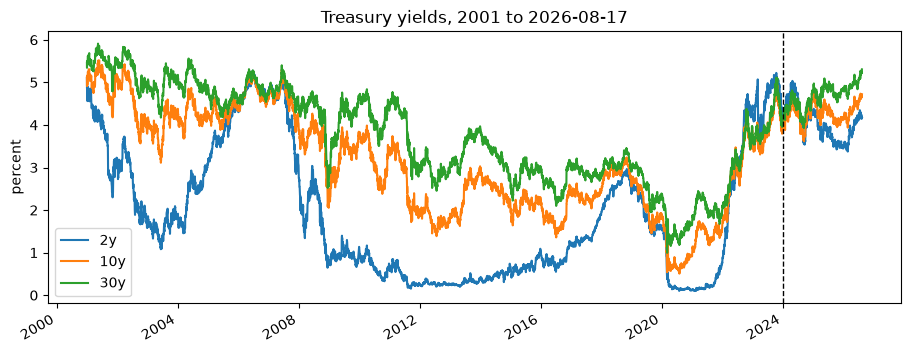

2y  = 4.3201
10y = 3.9294
30y = 4.0708
2s10s  = -0.3907
10s30s = 0.1414
30y percentile vs 2001-2024-01-02 history = 55.9593%
30y percentile vs full 2001-2026-08-17 history = 50.4491%


In [34]:
# 2.1


def question_2_1():
    fig, ax = plt.subplots(figsize=(11, 4))
    yields_data[["2y", "10y", "30y"]].plot(ax=ax)
    ax.axvline(START, color="black", linestyle="--", linewidth=1)
    ax.set_title("Treasury yields, 2001 to 2026-08-17")
    ax.set_ylabel("percent")
    ax.set_xlabel("")
    plt.show()

    row = yields_data.loc[START]
    hist = yields_data.loc[:START, "30y"]
    print(f"2y  = {row['2y']:.4f}")
    print(f"10y = {row['10y']:.4f}")
    print(f"30y = {row['30y']:.4f}")
    print(f"2s10s  = {row['10y'] - row['2y']:.4f}")
    print(f"10s30s = {row['30y'] - row['10y']:.4f}")
    print(
        f"30y percentile vs 2001-{START.date()} history = {(hist <= row['30y']).mean():.4%}"
    )
    print(
        f"30y percentile vs full 2001-{ASSESS.date()} history = {(yields_data['30y'] <= row['30y']).mean():.4%}"
    )


question_2_1()

On 2024-01-02 the curve was 2y 4.32, 10y 3.93, 30y 4.07, so 2s10s was -39bp (still inverted) while 10s30s was +14bp. The 30-year sat at the 56th percentile of its 2001-to-date history, which is the middle of the range, not a generational high. Anyone buying duration here was not buying a cheap long bond; they were buying an average-yield long bond against an inverted front end.

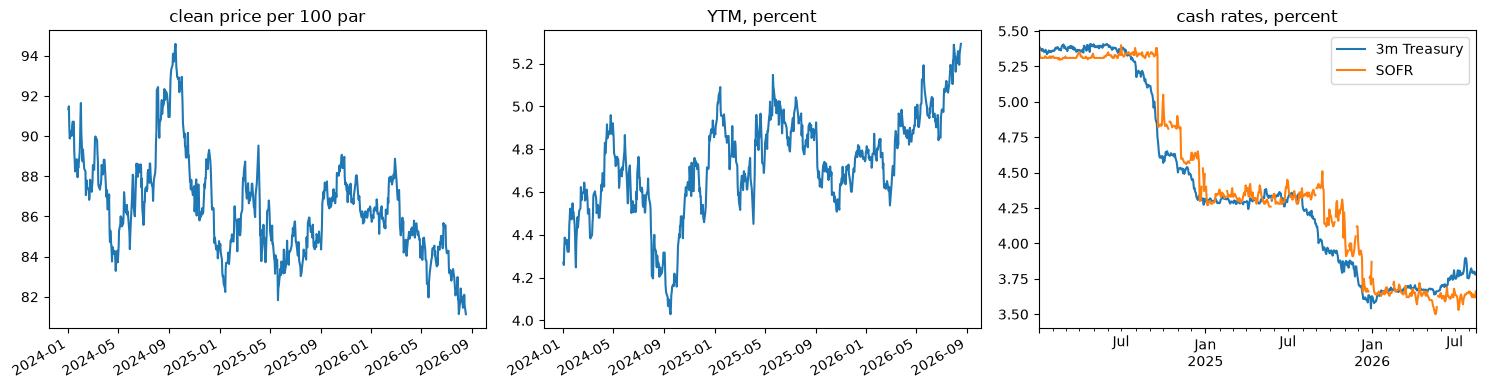

                clean      dirty    ytm
date                                   
2024-09-16  94.593750  94.908967  4.029
2025-01-14  82.242188  83.739470  5.090

cash on 2024-09-16:
3m Treasury    4.8609
SOFR           5.3800

cash on 2025-01-14:
3m Treasury    4.3045
SOFR           4.2800


In [35]:
# 2.2


def question_2_2():
    window = long_bond_data.loc[START:ASSESS]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    window["clean"].plot(ax=axes[0], title="clean price per 100 par")
    window["ytm"].plot(ax=axes[1], title="YTM, percent")
    cash_data.loc[START:ASSESS].plot(ax=axes[2], title="cash rates, percent")
    for ax in axes:
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

    lo = window["ytm"].idxmin()
    hi = window.loc[:"2025-03-31", "ytm"].idxmax()
    print(window.loc[[lo, hi], ["clean", "dirty", "ytm"]].to_string())
    print(f"\ncash on {lo.date()}:\n{cash_data.loc[lo].to_string()}")
    print(f"\ncash on {hi.date()}:\n{cash_data.loc[hi].to_string()}")


question_2_2()

2024-09-16 is the low-yield, high-price extreme of the whole sample: YTM 4.029 and clean 94.59, right before the Fed's first cut, with 3m bills still at 4.86 and SOFR at 5.38. Buying there is the version of the project where you pay up for duration on a cut narrative and give up a large negative carry. 2025-01-14 is the opposite extreme inside the allowed window: YTM 5.09 and clean 82.24, with cash already down to roughly 4.3. Buying there is the version where the long bond is cheap and the carry gap has mostly closed. Section 6.1 uses 2025-01-21 instead of the exact peak so the two entries are at least four months apart; the yield is 4.91 there, essentially the same trade.

In [36]:
# 3.1

BUY = pd.Timestamp("2024-09-16")
BENCH = "SOFR"


def question_3_1():
    print(f"purchase date = {BUY.date()}, cash benchmark = {BENCH}")
    print(long_bond_data.loc[BUY, ["clean", "accrued", "dirty", "ytm"]].to_string())
    print(yields_data.loc[BUY].to_string())
    print(cash_data.loc[BUY].to_string())


question_3_1()

purchase date = 2024-09-16, cash benchmark = SOFR
clean      94.593750
accrued     0.315217
dirty      94.908967
ytm         4.029000
2y     3.5509
10y    3.6176
30y    3.9285
3m Treasury    4.8609
SOFR           5.3800


I picked 2024-09-16, the trading day before the September 2024 FOMC. Evidence available that morning: the 30-year had rallied about 140bp of price from the spring, the curve was on the edge of dis-inverting, and the market was pricing a 50bp cut. Evidence I only have with hindsight: that this was the exact yield low of the entire 2024-2026 sample. So this is a conditional example of what a duration buyer at the best-looking moment of the cutting narrative actually got, not an ex-ante test of a rule. I chose SOFR over 3m Treasury because the alternative to holding a bond is an overnight-funded cash position, and SOFR is the rate actually earned on rolled cash with no term exposure of its own.

In [37]:
# 3.2


def bond_return(buy):
    tri = long_bond_data.loc[buy:ASSESS, "total return index"]
    dirty = long_bond_data.loc[buy:ASSESS, "dirty"]
    total = tri.iloc[-1] / tri.iloc[0] - 1
    price = dirty.iloc[-1] / dirty.iloc[0] - 1
    resid = (1 + total) / (1 + price) - 1
    return total, price, resid, dirty.iloc[0], dirty.iloc[-1]


def question_3_2(buy=BUY):
    total, price, resid, d_in, d_out = bond_return(buy)
    print(f"entry {buy.date()} dirty = {d_in:.6f}")
    print(f"exit  {ASSESS.date()} dirty = {d_out:.6f}")
    print(f"cumulative total return   = {total:.4%}")
    print(f"dirty price return        = {price:.4%}")
    print(f"coupon / reinvest residual= {resid:.4%}")
    print(f"reconcile (1+price)(1+resid)-1 = {(1 + price) * (1 + resid) - 1:.4%}")


question_3_2()

entry 2024-09-16 dirty = 94.908967
exit  2026-08-17 dirty = 81.152514
cumulative total return   = -6.9463%
dirty price return        = -14.4944%
coupon / reinvest residual= 8.8276%
reconcile (1+price)(1+resid)-1 = -6.9463%


The bond lost 6.95% cumulatively. The dirty price fell 14.49%, from 94.909 to 81.153, and the coupon and reinvestment leg added back 8.83%. Note the exit dirty price is measured on a coupon date, so accrued has already reset to 0.0197 and the price leg looks worse than the position was; the residual is what puts that coupon back. Two years of a 3.625% coupon was not enough to cover a 126bp rise in the bond's own yield on twelve-plus years of duration.

In [38]:
# 4.1


def cash_index(buy, benchmark=BENCH):
    idx = long_bond_data.loc[buy:ASSESS].index
    rate = cash_data[benchmark].reindex(idx).ffill()
    days = pd.Series(idx, index=idx).diff().dt.days.fillna(0)
    # rate observed at t-1 accrues over t-1 -> t, actual/360, compounded daily
    growth = 1 + rate.shift(1).fillna(0) / 100 * days / 360
    return growth.cumprod()


def question_4_1(buy=BUY, benchmark=BENCH):
    level = cash_index(buy, benchmark)
    print(
        f"{benchmark} roll, actual/360, compounded daily, rate lagged one observation"
    )
    print(
        f"{buy.date()} to {ASSESS.date()}: cumulative return = {level.iloc[-1] - 1:.4%}"
    )
    return level


cash_level = question_4_1()

SOFR roll, actual/360, compounded daily, rate lagged one observation
2024-09-16 to 2026-08-17: cumulative return = 8.3304%


The roll uses SOFR on actual/360 with daily compounding, and each day's rate is applied to the following interval only, so nothing is earned on a rate that had not yet printed. Weekend and holiday gaps accrue at the last observed rate over actual calendar days, which is how an overnight repo position actually rolls. That returns 8.33% over the same dates.

In [39]:
# 4.2


def performance(level, name):
    ret = level.pct_change().dropna()
    total = level.iloc[-1] / level.iloc[0] - 1
    vol = ret.std() * (252**0.5)
    mdd = (level / level.cummax() - 1).min()
    print(f"{name}: total = {total:.4%}, ann vol = {vol:.4%}, max drawdown = {mdd:.4%}")


def question_4_2(buy=BUY, benchmark=BENCH):
    performance(long_bond_data.loc[buy:ASSESS, "total return index"], "bond")
    performance(cash_index(buy, benchmark), f"{benchmark} roll")


question_4_2()

bond: total = -6.9463%, ann vol = 9.5567%, max drawdown = -11.7686%
SOFR roll: total = 8.3304%, ann vol = 0.1493%, max drawdown = 0.0000%


Cash beat the bond by 15.3 percentage points, at 0.15% annualized volatility against 9.56% and with no drawdown against -11.77%. The question attached to 2024-09-16 was whether locking in a 4.03% long yield ahead of the cutting cycle beat rolling overnight cash, and the answer is a flat no: the cuts happened at the front end, the long end sold off anyway, and the duration buyer paid for it twice.

In [40]:
# 5.1


def question_5_1(buy=BUY):
    table = yields_data.loc[[buy, ASSESS]].copy()
    table.loc["change"] = table.loc[ASSESS] - table.loc[buy]
    print(table.to_string())
    y30 = yields_data.loc[ASSESS, "30y"]
    print(
        f"\n30y percentile vs 2001-{ASSESS.date()} history = {(yields_data['30y'] <= y30).mean():.4%}"
    )


question_5_1()

                         2y     10y     30y
date                                       
2024-09-16 00:00:00  3.5509  3.6176  3.9285
2026-08-17 00:00:00  4.1753  4.7219  5.3060
change               0.6244  1.1043  1.3775

30y percentile vs 2001-2026-08-17 history = 93.5479%


From 2024-09-16 to 2026-08-17 the 2-year rose 62bp, the 10-year 110bp and the 30-year 138bp: a pure bear steepening, which is the worst shape for a long-bond holder. The 30-year now sits at the 93.5th percentile of its 2001-to-date history. The 5.216% auction yield in the article is a single primary-market clearing print for one newly issued 30-year on 2026-08-13, set by where bidders were willing to absorb $25bn of supply; the workbook's 30-year is a daily secondary-market generic quote. They track each other closely but differ by the auction concession, the exact settlement date, and the on-the-run versus generic distinction, which is why 5.216% at the auction and 5.306% on 2026-08-17 are both correct.

In [41]:
# 5.2


def question_5_2():
    y10 = yields_data["10y"].dropna()
    level = y10
    change = y10.diff().dropna()
    rows = []
    for lag in [1, 5, 21, 63]:
        rows.append(
            {
                "lag (days)": lag,
                "autocorr level": level.autocorr(lag),
                "autocorr change": change.autocorr(lag),
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))


question_5_2()

 lag (days)  autocorr level  autocorr change
          1        0.998804        -0.044741
          5        0.994727        -0.017554
         21        0.977944         0.021336
         63        0.932626         0.014592


Using the same statistic on both, the 10-year level has lag-1 autocorrelation of 0.999 and is still 0.978 at a month, while the daily change is -0.045 at lag 1 and essentially zero after that. Levels persist, changes do not. That is consistent with the article's fiscal and supply explanation, which is a slow-moving repricing of the term premium that shifts the level and keeps it there, rather than something forecastable day to day. What the workbook cannot establish is why: three yield series and two cash rates cannot separate deficits from corporate supply from a Warsh-uncertainty premium, since all three produce the same persistent level shift and none of the drivers appear in the data.

In [42]:
# 6.1

ALT_BUY = pd.Timestamp("2025-01-21")


def question_6_1():
    print(
        f"alternative purchase date = {ALT_BUY.date()} "
        f"({(ALT_BUY - BUY).days} days after {BUY.date()})"
    )
    print(long_bond_data.loc[[BUY, ALT_BUY], ["clean", "dirty", "ytm"]].to_string())
    print()
    question_3_2(ALT_BUY)
    print()
    question_4_1(ALT_BUY)
    print()
    question_4_2(ALT_BUY)


question_6_1()

alternative purchase date = 2025-01-21 (127 days after 2024-09-16)
                clean      dirty    ytm
date                                   
2024-09-16  94.593750  94.908967  4.029
2025-01-21  84.203125  85.769361  4.910

entry 2025-01-21 dirty = 85.769361
exit  2026-08-17 dirty = 81.152514
cumulative total return   = 2.9695%
dirty price return        = -5.3829%
coupon / reinvest residual= 8.8276%
reconcile (1+price)(1+resid)-1 = 2.9695%

SOFR roll, actual/360, compounded daily, rate lagged one observation
2025-01-21 to 2026-08-17: cumulative return = 6.5704%

bond: total = 2.9695%, ann vol = 9.3165%, max drawdown = -8.0263%
SOFR roll: total = 6.5704%, ann vol = 0.1455%, max drawdown = 0.0000%


Entering on 2025-01-21 at YTM 4.91 and dirty 85.769 turns the cumulative bond return from -6.95% to +2.97%, so the sign of the bond result flips. What survives is the ranking: the SOFR roll still wins, 6.57% against 2.97%, with 0.15% volatility against 9.32% and no drawdown against -8.03%. The coupon residual is identical at 8.83% because both entries cross the same four remaining coupon dates, so the entire difference is the entry price. Paying 94.909 for a 4.03% yield versus 85.769 for a 4.91% yield is 88bp of extra carry plus a nine-point-lower starting price against the same 5.29% exit, which is the whole gap.

In [43]:
# 6.2


def question_6_2():
    y = long_bond_data.loc[ASSESS, "ytm"] / 100
    coupon = float(specs_data.loc[specs_data["field"] == "coupon", "value"].iloc[0])
    maturity = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "maturity date", "value"].iloc[0]
    )
    n = round((maturity - ASSESS).days / 182.625)

    t = pd.Series(range(1, n + 1)) / 2
    cf = pd.Series([coupon / 2] * n)
    cf.iloc[-1] += 100
    disc = (1 + y / 2) ** (-2 * t)
    price = (cf * disc).sum()
    mod_dur = (t * cf * disc).sum() / price / (1 + y / 2)

    cash_rate = cash_data.loc[ASSESS, BENCH] / 100
    breakeven = (y - cash_rate) / mod_dur

    print(f"bond YTM = {y:.4%}, {BENCH} = {cash_rate:.4%}")
    print(f"semiannual periods to maturity = {n}")
    print(
        f"model price = {price:.4f} (quoted clean {long_bond_data.loc[ASSESS, 'clean']:.4f})"
    )
    print(f"modified duration = {mod_dur:.4f}")
    print(f"1y breakeven yield rise = {breakeven * 1e4:.2f} bp")


question_6_2()

bond YTM = 5.2920%, SOFR = 3.6600%
semiannual periods to maturity = 35
model price = 81.1279 (quoted clean 81.1328)
modified duration = 12.2126
1y breakeven yield rise = 13.36 bp


I hold the bond. Horizon is one year to 2026-08-17-plus-one, and the assumption the choice requires is that the 30-year yield rises less than 13.4bp over that year. That is the breakeven: the bond yields 5.292% against SOFR at 3.66%, a 163bp carry advantage, and with modified duration 12.21 it takes only a 13bp further sell-off to give that back. The decision is therefore a bet on the level stopping here, not on a rally. The observable that reverses it is the next few 30-year auctions: another tailing stop above roughly 5.45%, or a 30-year generic print above 5.43%, would put the position behind cash for the horizon and mean the term-premium repricing in the article is still running.